In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("../Data/Cleaned_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


# One-hot encoding for Multi-Category column

In [24]:
#One-hot encoding for 
person_home_ownership_dummy = pd.get_dummies(
    df['person_home_ownership'],
    prefix='person_home_ownership',
    drop_first=True
).astype('int')

In [25]:
loan_intent_dummy = pd.get_dummies(
    df['loan_intent'],
    prefix='loan_intent',
    drop_first=True
).astype('int')

The Reason for one-hot encoding is that there is no order in the data

In [26]:
#concating dummy column with main dataset
df = pd.concat([df, person_home_ownership_dummy, loan_intent_dummy], axis=1)
df = df.drop(['person_home_ownership', 'loan_intent'], axis=1)

# Ordinal encoding for "loan_grade" column

In [27]:
grade_map = {
    'A':0,
    'B':1,
    'C':2,
    'D':3,
    'E':4,
    'F':5,
    'G':6,
}
df['loan_grade'] = df['loan_grade'].map(grade_map)

Data in order, for here I use ordinal encoding

# Label encoding for "cb_person_default_on_file" column

In [28]:
cb_map = {
    'Y':1, 'N':0
}
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(cb_map)

In [29]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,9600,5.0,1,1000,11.14,0,0.10,0,2,0,1,0,1,0,0,0,0
1,25,9600,1.0,2,5500,12.87,1,0.57,0,3,0,0,0,0,0,1,0,0
2,23,65500,4.0,2,35000,15.23,1,0.53,0,2,0,0,1,0,0,1,0,0
3,24,54400,8.0,2,35000,14.27,1,0.55,1,4,0,0,1,0,0,1,0,0
4,21,9900,2.0,0,2500,7.14,1,0.25,0,2,0,1,0,0,0,0,0,1


All Feature Encoding done

# New Feature Extraction

In [30]:
df.insert(
    loc=2, column='person_monthly_income', 
    value=(df['person_income'] /12 ).round(2)
)

In [31]:
df.insert(
    loc=4, column='emp_stability', 
    value=(df['person_emp_length'] / df['person_age']).round(2)
)

In [32]:
df.insert(
    loc=13, column= 'credit_hist_ratio', 
    value=(df['cb_person_cred_hist_length'] / df['person_age']).round(2)
)

In [33]:
df.insert(
    loc=14, column= 'debt_burden_index', 
    value=((df['loan_amnt'] * (1+ df['loan_int_rate']/100))/df['person_income']).round(2)
)

In [34]:
df.head()

,person_age,person_income,person_monthly_income,person_emp_length,emp_stability,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,person_home_ownership_OTHER,credit_hist_ratio,debt_burden_index,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,9600,800.00,5.0,0.24,1,1000,11.14,0,0.10,...,0,0.10,0.12,1,0,1,0,0,0,0
1,25,9600,800.00,1.0,0.04,2,5500,12.87,1,0.57,...,0,0.12,0.65,0,0,0,0,1,0,0
2,23,65500,5458.33,4.0,0.17,2,35000,15.23,1,0.53,...,0,0.09,0.62,0,1,0,0,1,0,0
3,24,54400,4533.33,8.0,0.33,2,35000,14.27,1,0.55,...,0,0.17,0.74,0,1,0,0,1,0,0
4,21,9900,825.00,2.0,0.10,0,2500,7.14,1,0.25,...,0,0.10,0.27,1,0,0,0,0,0,1


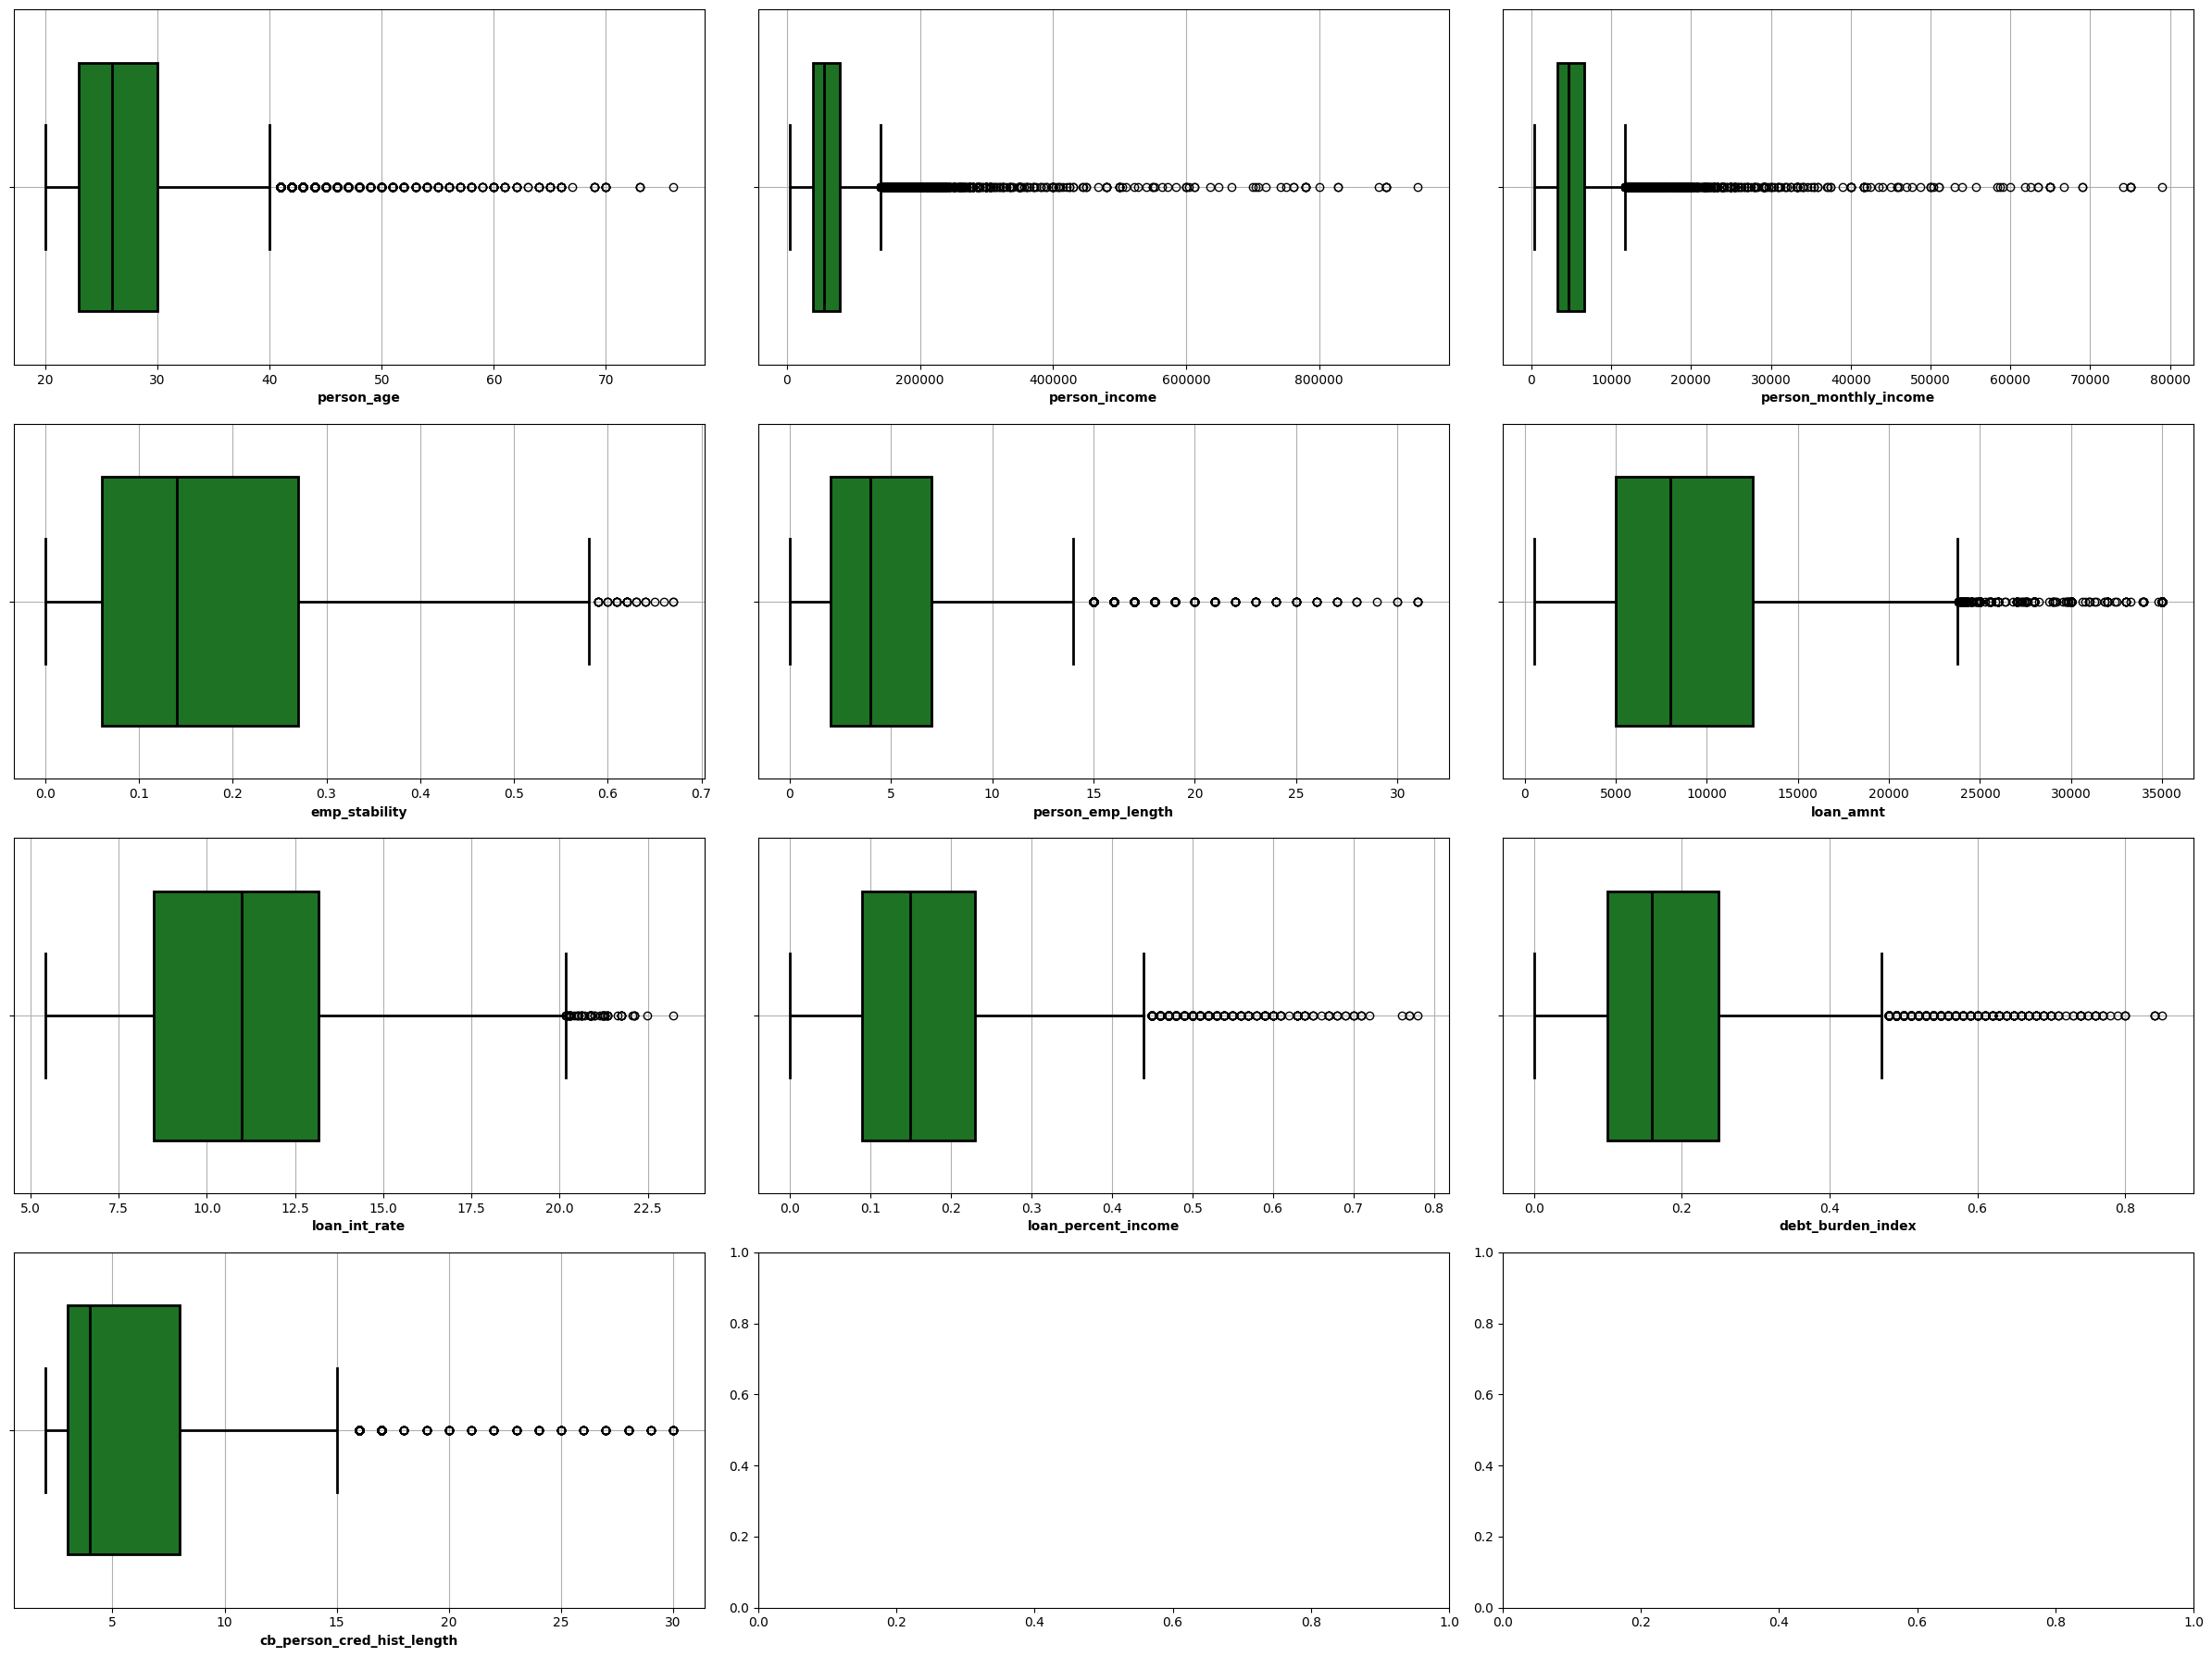

In [37]:
num_cols = [
    'person_age', 'person_income', 
    'person_monthly_income', 'emp_stability',
    'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 
    'debt_burden_index', 'cb_person_cred_hist_length'
] 

fig, axes = plt.subplots(4, 3, figsize=(24, 18))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(
        x = df[col],
        ax =ax,
        color= "#0F8018",
        linewidth=2,
        linecolor="#000000", 
        width=0.7
    )
    ax.set_xlabel(col, weight='bold')
    ax.grid(True)
plt.tight_layout()

In [38]:
for col in num_cols:
    df[col] = np.log1p(df[col])

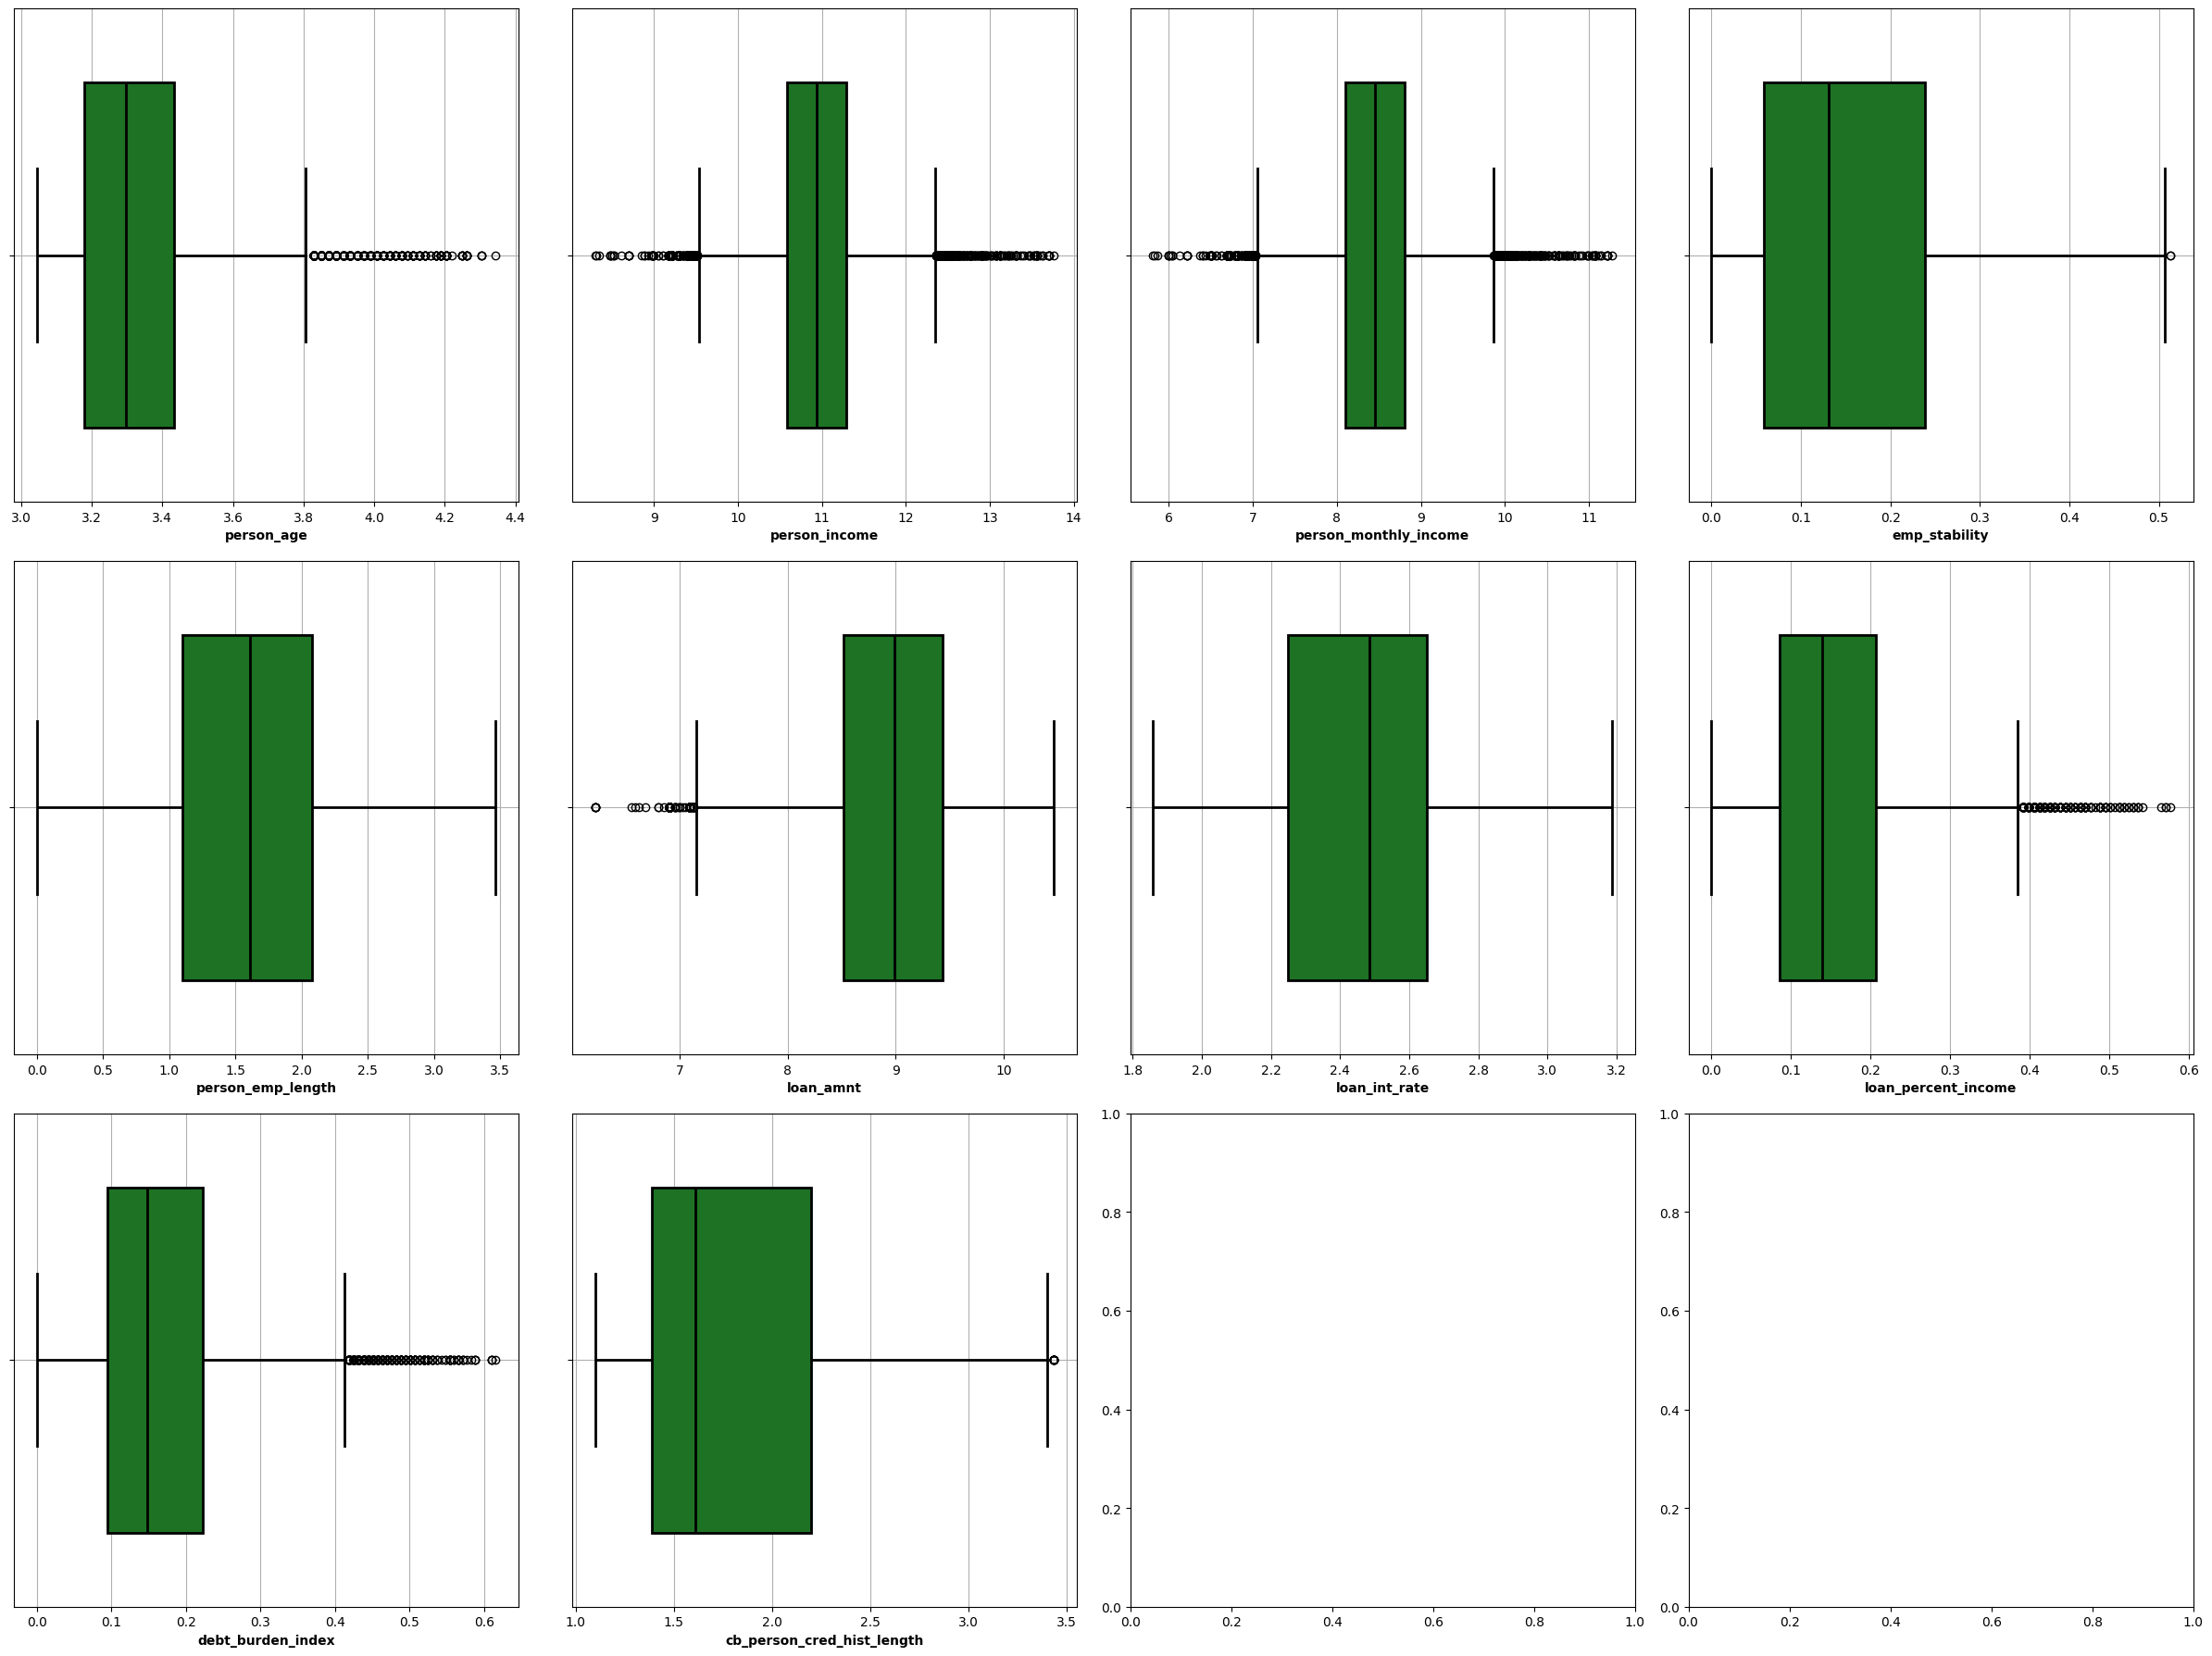

In [39]:
num_cols = [
    'person_age', 'person_income', 
    'person_monthly_income', 'emp_stability',
    'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 
    'debt_burden_index', 'cb_person_cred_hist_length'
] 

fig, axes = plt.subplots(3, 4, figsize=(24, 18))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(
        x = df[col],
        ax =ax,
        color= "#0F8018",
        linewidth=2,
        linecolor="#000000", 
        width=0.7
    )
    ax.set_xlabel(col, weight='bold')
    ax.grid(True)
plt.tight_layout()

In [40]:
df.head()

,person_age,person_income,person_monthly_income,person_emp_length,emp_stability,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,person_home_ownership_OTHER,credit_hist_ratio,debt_burden_index,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,3.091042,9.169623,6.685861,1.791759,0.215111,1,6.908755,2.496506,0,0.095310,...,0,0.10,0.113329,1,0,1,0,0,0,0
1,3.258097,9.169623,6.685861,0.693147,0.039221,2,8.612685,2.629728,1,0.451076,...,0,0.12,0.500775,0,0,0,0,1,0,0
2,3.178054,11.089821,8.605081,1.609438,0.157004,2,10.463132,2.786861,1,0.425268,...,0,0.09,0.482426,0,1,0,0,1,0,0
3,3.218876,10.904138,8.419433,2.197225,0.285179,2,10.463132,2.725890,1,0.438255,...,0,0.17,0.553885,0,1,0,0,1,0,0
4,3.091042,9.200391,6.716595,1.098612,0.095310,0,7.824446,2.096790,1,0.223144,...,0,0.10,0.239017,1,0,0,0,0,0,1


In [42]:
df.to_csv("../Data/Preprocessed_data.csv", index=False)